# Decision Trees From Scratch

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

### Decision Tree Calculation

Decision trees are supervised models that make predictions with hierarchical if-else decisions

A tree has:
- root node
- inner nodes
- branches
- leaf nodes

$$\text{\newline\newline\newline\newline\newline\newline\newline\newline}$$

For classification, we want to maximize purity/minimize impurity:

Entropy:
$$H(S) = -\sum_{i=1}^{k}p_i\log_2(p_i)$$

Gini impurity:
$$Gini(S) = 1 - \sum_{i=1}^{k}p_i^2$$

Information gain:
$$IG = impurity_{root} - \left(w^L impurity_L + w^R impurity_R\right)$$

$$\text{\newline\newline\newline\newline\newline\newline\newline\newline}$$

For regression trees, we split by reducing variance/squared error:

Mean squared error:
$$MSE = \frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - \bar{y})^2$$

Reduction in variance:
$$RIV = variance_{root} - \left(w^L variance_L + w^R variance_R\right)$$

For continuous variables:
1. Sort the values for a feature
2. Create thresholds from midpoints
3. For each threshold, split data and compute IG

In [74]:
def entropy(Y):
    '''
    Params:
        Y - sample target values

    Returns:
        entropy - impurity score
    '''

    values, counts = np.unique(Y, return_counts=True)
    p = counts / len(Y)
    p = p[p > 0]

    return -np.sum(p * np.log2(p))


def gini(Y):
    '''
    Params:
        Y - sample target values

    Returns:
        gini - impurity score
    '''

    values, counts = np.unique(Y, return_counts=True)
    p = counts / len(Y)

    return 1 - np.sum(p ** 2)


def mse(Y):
    '''
    Params:
        Y - sample target values

    Returns:
        mse - mean squared error from the node mean
    '''

    if len(Y) == 0:
        return 0

    return np.mean((Y - np.mean(Y)) ** 2)


def majority_class(Y, global_majority=None):
    '''
    Params:
        Y - sample target values
        global_majority - class to use if there is a tie

    Returns:
        selected_class - most frequent class
    '''

    values, counts = np.unique(Y, return_counts=True)

    max_count = np.max(counts)
    tied_values = values[counts == max_count]

    if len(tied_values) > 1 and global_majority is not None:
        return global_majority

    return tied_values[0]

### Decision Tree Implementation

In [75]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, 
                 value=None, impurity=None, n_samples=None, depth=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.impurity = impurity
        self.n_samples = n_samples
        self.depth = depth

    def is_leaf(self):
        return self.left is None and self.right is None


class DecisionTree:
    def __init__(self, task="classification", criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                 max_features=None, max_leaf_nodes=None, min_impurity_decrease=0):
        self.root = None
        self.global_majority = None
        self.n_leaves = 0

        self.task = task # tasks: classification, regression
        self.criterion = criterion # criterion: gini, entropy, mse
        
        # hyperparameters for pre-pruning
        self.max_depth = max_depth # max tree depth
        self.min_samples_split = min_samples_split # min samples required to split a node
        self.min_samples_leaf = min_samples_leaf # min samples required at a leaf node
        self.max_features = max_features # num of features to consider for best split
        self.max_leaf_nodes = max_leaf_nodes # max leaf nodes
        self.min_impurity_decrease = min_impurity_decrease # min impurity decrease required to split

    def impurity(self, Y):
        if self.task == "regression":
            return mse(Y)

        if self.criterion == "entropy":
            return entropy(Y)

        return gini(Y)

    def leaf_value(self, Y):
        if self.task == "regression":
            return np.mean(Y)

        return majority_class(Y, self.global_majority)

    def get_feature_indices(self, n_features):
        if self.max_features is None:
            return np.arange(n_features)

        if self.max_features == "sqrt":
            num_features = max(1, int(np.sqrt(n_features)))
        elif self.max_features == "log2":
            num_features = max(1, int(np.log2(n_features)))
        elif isinstance(self.max_features, float):
            num_features = max(1, int(self.max_features * n_features))
        else:
            num_features = int(self.max_features)

        num_features = min(num_features, n_features)

        return np.random.choice(n_features, num_features, replace=False)

    def best_split(self, X, Y):
        m, n = X.shape
        parent_impurity = self.impurity(Y)

        best_gain = 0
        best_feature = None
        best_threshold = None

        feature_indices = self.get_feature_indices(n)

        for feature in feature_indices:
            values = np.unique(X[:, feature])

            if len(values) <= 1:
                continue

            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = ~left_idx

                Y_left = Y[left_idx]
                Y_right = Y[right_idx]

                if len(Y_left) < self.min_samples_leaf or len(Y_right) < self.min_samples_leaf:
                    continue

                left_weight = len(Y_left) / m
                right_weight = len(Y_right) / m

                child_impurity = (left_weight * self.impurity(Y_left)) + (right_weight * self.impurity(Y_right))
                gain = parent_impurity - child_impurity

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def stopping_condition(self, Y, depth):
        if self.max_depth is not None and depth >= self.max_depth:
            return True

        if len(Y) < self.min_samples_split:
            return True

        if self.task == "classification" and len(np.unique(Y)) == 1:
            return True

        if self.max_leaf_nodes is not None and self.n_leaves >= self.max_leaf_nodes:
            return True

        return False

    def build_tree(self, X, Y, depth=0):
        node_value = self.leaf_value(Y)
        node_impurity = self.impurity(Y)

        if self.stopping_condition(Y, depth):
            self.n_leaves += 1
            return Node(value=node_value, impurity=node_impurity, n_samples=len(Y), depth=depth)

        feature, threshold, gain = self.best_split(X, Y)

        if feature is None or gain < self.min_impurity_decrease:
            self.n_leaves += 1
            return Node(value=node_value, impurity=node_impurity, n_samples=len(Y), depth=depth)

        left_idx = X[:, feature] <= threshold
        right_idx = ~left_idx

        left = self.build_tree(X[left_idx], Y[left_idx], depth + 1)
        right = self.build_tree(X[right_idx], Y[right_idx], depth + 1)

        return Node(feature=feature, threshold=threshold, left=left, right=right, value=node_value, 
                    impurity=node_impurity, n_samples=len(Y), depth=depth)

    def fit(self, X, Y):
        if self.task == "classification":
            self.global_majority = majority_class(Y)

        self.n_leaves = 0
        self.root = self.build_tree(X, Y)

    def predict_one(self, x, node):
        while not node.is_leaf():
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.value

    def predict_from_node(self, X, node):
        return np.array([self.predict_one(x, node) for x in X])

    def predict(self, X):
        return self.predict_from_node(X, self.root)

    def num_leaves(self, node=None):
        if node is None:
            node = self.root

        if node.is_leaf():
            return 1

        return self.num_leaves(node.left) + self.num_leaves(node.right)

    def node_loss(self, Y, pred):
        if self.task == "regression":
            return np.sum((Y - pred) ** 2)

        return np.sum(Y != pred)

    def prune_node(self, node, X_val, Y_val, alpha=0):
        if node.is_leaf() or len(Y_val) == 0:
            return node

        left_idx = X_val[:, node.feature] <= node.threshold
        right_idx = ~left_idx

        node.left = self.prune_node(node.left, X_val[left_idx], Y_val[left_idx], alpha)
        node.right = self.prune_node(node.right, X_val[right_idx], Y_val[right_idx], alpha)

        subtree_pred = self.predict_from_node(X_val, node)
        subtree_cost = self.node_loss(Y_val, subtree_pred) + (alpha * self.num_leaves(node))

        leaf_pred = np.full(len(Y_val), node.value)
        leaf_cost = self.node_loss(Y_val, leaf_pred) + alpha

        if leaf_cost <= subtree_cost:
            node.left = None
            node.right = None

        return node

    def cost_complexity_prune(self, X_val, Y_val, alpha=0):
        self.root = self.prune_node(self.root, X_val, Y_val, alpha)

    def print_tree(self, feature_names=None):

        def get_label(node):
            if node.is_leaf():
                return "Predict: " + str(round(node.value, 4)) if isinstance(node.value, float) else "Predict: " + str(node.value)

            feature_name = node.feature if feature_names is None else feature_names[node.feature]
            return str(feature_name) + " <= " + str(round(node.threshold, 4))

        def get_depth(node):
            if node is None or node.is_leaf():
                return 1

            return 1 + max(get_depth(node.left), get_depth(node.right))

        def get_leaf_count(node):
            if node is None:
                return 0

            if node.is_leaf():
                return 1

            return get_leaf_count(node.left) + get_leaf_count(node.right)

        def draw_node(node, x, y, dx):
            label = get_label(node)

            ax.text(x, y, label, ha="center", va="center", bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

            if node.is_leaf():
                return

            child_y = y - 1
            left_x = x - dx
            right_x = x + dx

            ax.plot([x, left_x], [y - 0.1, child_y + 0.1])
            ax.plot([x, right_x], [y - 0.1, child_y + 0.1])

            ax.text((x + left_x) / 2, (y + child_y) / 2, "True", ha="center", va="center")
            ax.text((x + right_x) / 2, (y + child_y) / 2, "False", ha="center", va="center")

            draw_node(node.left, left_x, child_y, dx / 2)
            draw_node(node.right, right_x, child_y, dx / 2)

        depth = get_depth(self.root)
        leaves = get_leaf_count(self.root)

        fig, ax = plt.subplots(figsize=(max(10, leaves * 2), max(6, depth * 1.5)))

        draw_node(self.root, 0, 0, leaves / 2)

        ax.axis("off")
        plt.show()

### Pre-Pruning and Post-Pruning

Pre-pruning occurs during training, using hyperparameters to limit tree size

Pre-pruning hyperparameters:
- max depth
- min samples required to split
- min samples required at a leaf
- number of features considered for each split
- max leaf nodes
- min impurity decrease

$$\text{\newline\newline\newline\newline\newline\newline\newline\newline}$$

Post-pruning grows the tree first, then cuts branches that do not help enough

Cost complexity pruning:
$$cost = error + (alpha \cdot leaves)$$

If replacing a subtree with one leaf gives lower cost, the subtree gets pruned

### Classification Tree Testing

/var/folders/b4/y3_r14594wv4rhr7mbnnjtvr0000gn/T/ipykernel_69222/2374592502.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Feature Names:
<StringArray>
[                       'IQ',           'Prev_Sem_Result',
                      'CGPA',      'Academic_Performance',
    'Extra_Curricular_Score',      'Communication_Skills',
        'Projects_Completed', 'Internship_Experience_Yes']
Length: 8, dtype: str

Predictions:
[0 0 0 ... 0 0 0]

Actual:
[0 0 0 ... 0 0 0]

Accuracy (Evaluation of training):
0.9594

Tree:


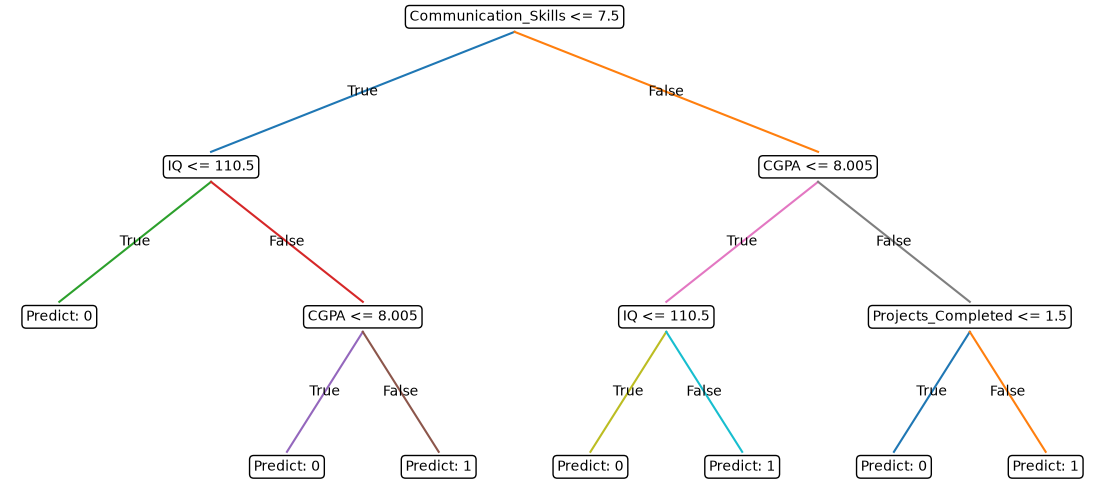

In [76]:
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sahilislam007/college-student-placement-factors-dataset",
  "college_student_placement_dataset.csv",
)

X_df = pd.get_dummies(df.drop(columns=["Placement", "College_ID"]), drop_first=True)
X = X_df.values.astype(float)
Y = df["Placement"].map({"No": 0, "Yes": 1}).values

tree = DecisionTree(
    task="classification",
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    min_impurity_decrease=0
)

tree.fit(X, Y)
Y_pred = tree.predict(X)

accuracy = np.mean(Y_pred == Y)

print("Feature Names:")
print(X_df.columns.values)

print("\nPredictions:")
print(Y_pred)

print("\nActual:")
print(Y)

print("\nAccuracy (Evaluation of training):")
print(accuracy)

print("\nTree:")
tree.print_tree(feature_names=X_df.columns.values)

### Regression Tree Testing

Feature Names:
<StringArray>
[                       'IQ',           'Prev_Sem_Result',
      'Academic_Performance',    'Extra_Curricular_Score',
      'Communication_Skills',        'Projects_Completed',
 'Internship_Experience_Yes',             'Placement_Yes']
Length: 8, dtype: str

Predictions:
[6.60027537 5.33363218 5.33363218 ... 5.97050127 9.07481655 9.69003971]

Actual:
[6.28 5.37 5.83 ... 6.25 8.92 9.77]

RSS (Evaluation of training):
1122.9226325397894

Tree:


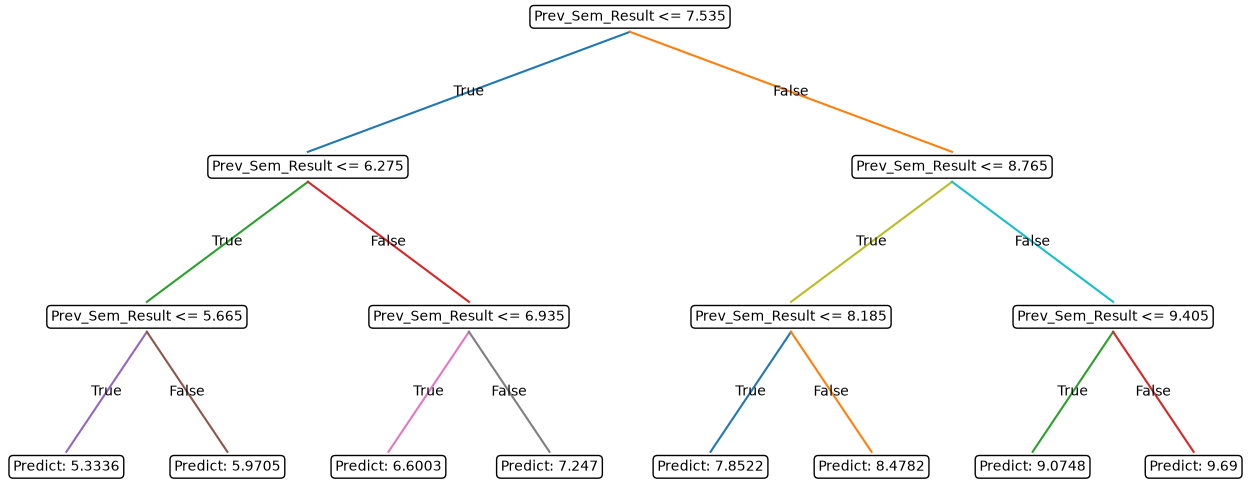

In [77]:

X_df = pd.get_dummies(df.drop(columns=["CGPA", "College_ID"]), drop_first=True)
X = X_df.values.astype(float)
Y = df["CGPA"].values.astype(float)

tree = DecisionTree(
    task="regression",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1
)

tree.fit(X, Y)
Y_pred = tree.predict(X)

rss = np.sum((Y - Y_pred) ** 2)

print("Feature Names:")
print(X_df.columns.values)

print("\nPredictions:")
print(Y_pred)

print("\nActual:")
print(Y)

print("\nRSS (Evaluation of training):")
print(rss)

print("\nTree:")
tree.print_tree(feature_names=X_df.columns.values)

### Train Test Split and Evaluation

In [78]:
def train_test_split(X, Y, test_size=0.2, seed=42):
    '''
    Params:
        X - sample data
        Y - sample target values
        test_size - fraction of data for testing
        seed - random seed

    Returns:
        X_train, X_test, Y_train, Y_test
    '''

    np.random.seed(seed)

    m = X.shape[0]
    indices = np.random.permutation(m)

    test_m = int(m * test_size)

    test_idx = indices[:test_m]
    train_idx = indices[test_m:]

    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]


def accuracy_score(Y_true, Y_pred):
    return np.mean(Y_true == Y_pred)


def rss_score(Y_true, Y_pred):
    return np.sum((Y_true - Y_pred) ** 2)


def r2_score(Y_true, Y_pred):
    rss = np.sum((Y_true - Y_pred) ** 2)
    tss = np.sum((Y_true - np.mean(Y_true)) ** 2)

    return 1 - (rss / tss)

### Cost Complexity Pruning Testing

RSS Before Pruning:
425.01599999999996


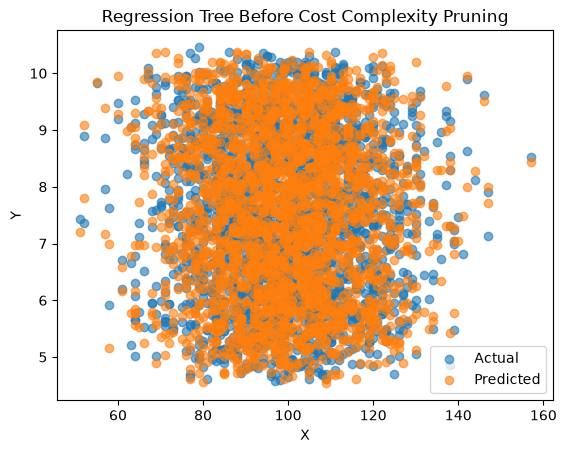


RSS After Pruning:
269.7211875079721


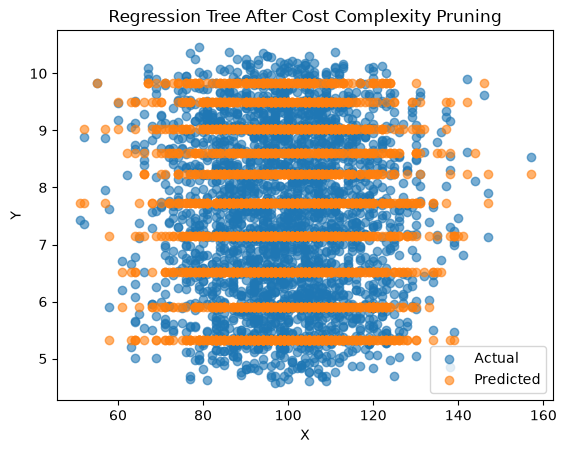

In [79]:

X_df = pd.get_dummies(df.drop(columns=["CGPA", "College_ID"]), drop_first=True)
X = X_df.values.astype(float)
Y = df["CGPA"].values.astype(float)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, seed=42)

tree = DecisionTree(
    task="regression",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

tree.fit(X_train, Y_train)

Y_pred_before = tree.predict(X_test)
rss_before = rss_score(Y_test, Y_pred_before)

tree.cost_complexity_prune(X_test, Y_test, alpha=10)

Y_pred_after = tree.predict(X_test)
rss_after = rss_score(Y_test, Y_pred_after)

print("RSS Before Pruning:")
print(rss_before)

plt.scatter(X_test[:, 0], Y_test, alpha=0.6, label="Actual")
plt.scatter(X_test[:, 0], Y_pred_before, alpha=0.6, label="Predicted")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Tree Before Cost Complexity Pruning")
plt.legend()
plt.show()

print("\nRSS After Pruning:")
print(rss_after)

plt.scatter(X_test[:, 0], Y_test, alpha=0.6, label="Actual")
plt.scatter(X_test[:, 0], Y_pred_after, alpha=0.6, label="Predicted")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Tree After Cost Complexity Pruning")
plt.legend()
plt.show()

### Tree Ensembles

Bagging:
1. Create many bootstrapped datasets with sampling replacement (randomized versions of the original dataset)
2. Train each tree on a unique bootstrapped dataset; trees are trained all at once
3. Prediction
    - Classification uses majority voting
    - Regression uses averaging

Random forest:
- Same as bagging but with feature randomness
- At each split, randomly select a subset of features and only choose the best split from that subset

$$\text{\newline\newline\newline\newline\newline\newline\newline\newline}$$

Gradient Boosting:
1. Start with a base prediction
    - Classification: log-odds or class probability baseline
    - Regression: mean of Y
2. Train trees sequentially, where each new tree tries to correct the current ensemble's errors
    1. Calculate residuals/errors (current prediction - base prediction)
    2. Train a new tree on those residuals
    3. Add the new tree to the ensemble
    4. Repeat
3. Prediction
    - Classification adds tree outputs, then converts the final score into class probabilities/classes
    - Regression adds the outputs of all trees

XGBoost:
1. Start with a base prediction
2. Train trees sequentially, where each new tree tries to reduce the loss
    1. Calculate gradients and hessians (first-order and second-order derivatives respectively)
    2. Train a regularized tree using the derivatives
        - L1 and L2 regularization to help reduce overfitting
        - Split penalties to discourage unnecessary branches
    3. Add the new tree to the ensemble
    4. Repeat
3. Prediction
    - Classification adds tree outputs, then converts the final score into class probabilities/classes
    - Regression adds the outputs of all trees

In [80]:
class BaggingEnsemble:
    def __init__(self, n_estimators=20, task="classification", **tree_params):
        self.n_estimators = n_estimators
        self.task = task
        self.tree_params = tree_params
        self.trees = []

    def fit(self, X, Y):
        m = X.shape[0]
        self.trees = []

        for i in range(self.n_estimators):
            idx = np.random.choice(m, m, replace=True)

            X_sample = X[idx]
            Y_sample = Y[idx]

            tree = DecisionTree(task=self.task, **self.tree_params)
            tree.fit(X_sample, Y_sample)

            self.trees.append(tree)

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])

        if self.task == "regression":
            return np.mean(preds, axis=0)

        final_preds = []

        for sample_preds in preds.T:
            final_preds.append(majority_class(sample_preds))

        return np.array(final_preds)


class RandomForest:
    def __init__(self, n_estimators=20, task="classification", max_features="sqrt", **tree_params):
        self.model = BaggingEnsemble(n_estimators=n_estimators, task=task, max_features=max_features, **tree_params)

    def fit(self, X, Y):
        self.model.fit(X, Y)

    def predict(self, X):
        return self.model.predict(X)


class GradientBoosting:
    def __init__(self, n_estimators=20, learning_rate=0.1, max_depth=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.base_pred = None
        self.trees = []

    def fit(self, X, Y):
        self.base_pred = np.mean(Y)
        current_pred = np.full(len(Y), self.base_pred)

        self.trees = []

        for i in range(self.n_estimators):
            residuals = Y - current_pred

            tree = DecisionTree(
                task="regression",
                max_depth=self.max_depth,
                min_samples_leaf=2
            )

            tree.fit(X, residuals)

            update = tree.predict(X)
            current_pred = current_pred + (self.learning_rate * update)

            self.trees.append(tree)

    def predict(self, X):
        pred = np.full(X.shape[0], self.base_pred)

        for tree in self.trees:
            pred = pred + (self.learning_rate * tree.predict(X))

        return pred


class XGBoostNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

class XGBoost:
    def __init__(self, n_estimators=20, learning_rate=0.1, max_depth=2, min_samples_split=2, min_samples_leaf=1, reg_lambda=1.0, gamma=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.reg_lambda = reg_lambda
        self.gamma = gamma
        self.base_pred = None
        self.trees = []

    def leaf_value(self, gradients, hessians):
        return -np.sum(gradients) / (np.sum(hessians) + self.reg_lambda)

    def gain(self, G_left, H_left, G_right, H_right, G_total, H_total):
        left_score = (G_left ** 2) / (H_left + self.reg_lambda)
        right_score = (G_right ** 2) / (H_right + self.reg_lambda)
        total_score = (G_total ** 2) / (H_total + self.reg_lambda)

        return 0.5 * (left_score + right_score - total_score) - self.gamma

    def best_split(self, X, gradients, hessians):
        m, n = X.shape

        G_total = np.sum(gradients)
        H_total = np.sum(hessians)

        best_gain = 0
        best_feature = None
        best_threshold = None

        for feature in range(n):
            values = np.sort(np.unique(X[:, feature]))

            if len(values) <= 1:
                continue

            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = ~left_idx

                if np.sum(left_idx) < self.min_samples_leaf or np.sum(right_idx) < self.min_samples_leaf:
                    continue

                G_left = np.sum(gradients[left_idx])
                H_left = np.sum(hessians[left_idx])

                G_right = np.sum(gradients[right_idx])
                H_right = np.sum(hessians[right_idx])

                split_gain = self.gain(G_left, H_left, G_right, H_right, G_total, H_total)

                if split_gain > best_gain:
                    best_gain = split_gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def build_tree(self, X, gradients, hessians, depth=0):
        if depth >= self.max_depth:
            value = self.leaf_value(gradients, hessians)
            return XGBoostNode(value=value)

        if X.shape[0] < self.min_samples_split:
            value = self.leaf_value(gradients, hessians)
            return XGBoostNode(value=value)

        feature, threshold, split_gain = self.best_split(X, gradients, hessians)

        if feature is None or split_gain <= 0:
            value = self.leaf_value(gradients, hessians)
            return XGBoostNode(value=value)

        left_idx = X[:, feature] <= threshold
        right_idx = ~left_idx

        left = self.build_tree(
            X[left_idx],
            gradients[left_idx],
            hessians[left_idx],
            depth + 1
        )

        right = self.build_tree(
            X[right_idx],
            gradients[right_idx],
            hessians[right_idx],
            depth + 1
        )

        return XGBoostNode(
            feature=feature,
            threshold=threshold,
            left=left,
            right=right
        )

    def predict_one_tree(self, x, node):
        while not node.is_leaf():
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.value

    def predict_tree(self, X, tree):
        return np.array([self.predict_one_tree(x, tree) for x in X])

    def fit(self, X, Y):
        self.base_pred = np.mean(Y)
        current_pred = np.full(len(Y), self.base_pred)

        self.trees = []

        for i in range(self.n_estimators):
            gradients = current_pred - Y
            hessians = np.ones(len(Y))

            tree = self.build_tree(X, gradients, hessians)

            update = self.predict_tree(X, tree)
            current_pred = current_pred + (self.learning_rate * update)

            self.trees.append(tree)

    def predict(self, X):
        pred = np.full(X.shape[0], self.base_pred)

        for tree in self.trees:
            pred = pred + (self.learning_rate * self.predict_tree(X, tree))

        return pred
    

### Bagging and Random Forest Testing

In [81]:

X_df = pd.get_dummies(df.drop(columns=["Placement", "College_ID"]), drop_first=True)
X = X_df.values.astype(float)
Y = df["Placement"].map({"No": 0, "Yes": 1}).values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, seed=42)

tree = DecisionTree(
    task="classification",
    max_depth=4,
    min_samples_leaf=3
)

tree.fit(X_train, Y_train)
Y_pred_tree = tree.predict(X_test)

bagging = BaggingEnsemble(
    n_estimators=25,
    task="classification",
    max_depth=4,
    min_samples_leaf=3
)

bagging.fit(X_train, Y_train)
Y_pred_bagging = bagging.predict(X_test)

forest = RandomForest(
    n_estimators=25,
    task="classification",
    max_depth=4,
    min_samples_leaf=3,
    max_features="sqrt"
)

forest.fit(X_train, Y_train)
Y_pred_forest = forest.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(Y_test, Y_pred_tree))

print("\nBagging Accuracy:")
print(accuracy_score(Y_test, Y_pred_bagging))

print("\nRandom Forest Accuracy:")
print(accuracy_score(Y_test, Y_pred_forest))

Decision Tree Accuracy:
1.0

Bagging Accuracy:
1.0

Random Forest Accuracy:
0.9504


### Gradient Boosting and XGBoost Testing

Gradient Boosting

RSS (Evaluation of testing):
209.99775230913212

R2 (Evaluation of testing):
0.9604528447361982


XGBoost

RSS (Evaluation of testing):
209.8421604144643

R2 (Evaluation of testing):
0.9604821460822772


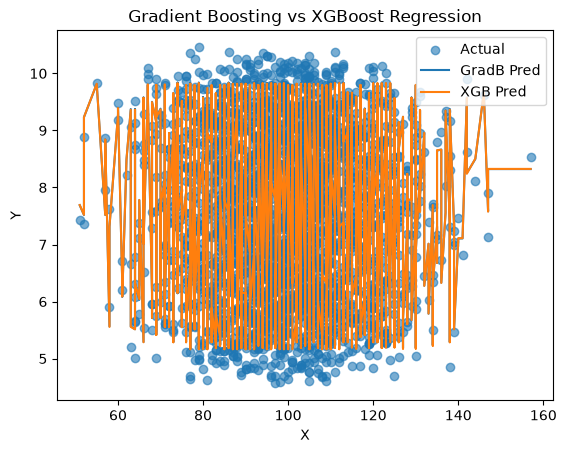

In [82]:

X_df = pd.get_dummies(df.drop(columns=["CGPA", "College_ID"]), drop_first=True)
X = X_df.values.astype(float)
Y = df["CGPA"].values.astype(float)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, seed=42)

boost = GradientBoosting(
    n_estimators=40,
    learning_rate=0.1,
    max_depth=2
)

boost.fit(X_train, Y_train)
Y_pred_boost = boost.predict(X_test)

rss_boost = rss_score(Y_test, Y_pred_boost)
r2_boost = r2_score(Y_test, Y_pred_boost)

print("Gradient Boosting")
print("\nRSS (Evaluation of testing):")
print(rss_boost)

print("\nR2 (Evaluation of testing):")
print(r2_boost)

xgb = XGBoost(
    n_estimators=40,
    learning_rate=0.1,
    max_depth=2,
    reg_lambda=1.0,
    gamma=0.0
)

xgb.fit(X_train, Y_train)
Y_pred_xgb = xgb.predict(X_test)

rss_xgb = rss_score(Y_test, Y_pred_xgb)
r2_xgb = r2_score(Y_test, Y_pred_xgb)

print("\n\nXGBoost")
print("\nRSS (Evaluation of testing):")
print(rss_xgb)

print("\nR2 (Evaluation of testing):")
print(r2_xgb)

sort_idx = np.argsort(X_test[:, 0])

plt.scatter(X_test[:, 0], Y_test, alpha=0.6, label="Actual")
plt.plot(X_test[sort_idx, 0], Y_pred_boost[sort_idx], label="GradB Pred")
plt.plot(X_test[sort_idx, 0], Y_pred_xgb[sort_idx], label="XGB Pred")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Gradient Boosting vs XGBoost Regression")
plt.legend()
plt.show()